# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:** Fausto Geovany Garrido Ruíz 
**Carnet:** 202605822  
**Fecha:** 18/05/2026
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")


Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [42]:
# Completa tus datos
NOMBRE = "Fausto Geovany Garrido Ruíz"   
CARNET = "202605822"         

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Fausto Geovany Garrido Ruíz
Carnet     : 202605822


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [43]:
# Carga el CSV desde URL_SISMOS con pd.read_csv() y guárdalo en 'sismos'
sismos = pd.read_csv(URL_SISMOS)

print(sismos.head())
print(f"\nDimensiones: {sismos.shape}")
print(f"\nTipos de datos:\n{sismos.dtypes}")
print(f"\nValores nulos:\n{sismos.isnull().sum()}")


                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW of Atiquipa, Peru  eart

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [44]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

contador = 0
for indice, fila in sismos.iterrows():
    if contador >= 5:
        break
        print(f"Sismo {contador+1}: mag={fila['mag']:.2f} | prof={fila['depth']} km | lugar={fila['place']}")
    

    contador += 1


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [45]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

mag_max = 0
idx_max = None

for idx, mag in enumerate(sismos['mag']):
   if mag > mag_max:
        mag_max = mag
        idx_max = idx
    

print("Sismo más intenso:")
print(sismos.loc[idx_max, ['place', 'mag', 'depth', 'magType']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")
print(sismos.sort_values('depth', ascending=False)[['place', 'mag', 'depth', 'magType']].head())

print("\nTop 5 sismos de mayor magnitud:")
print(sismos.sort_values('mag', ascending=False)[['place', 'mag', 'depth', 'magType']].head())


Sismo más intenso:
place      2024 Noto Peninsula, Japan Earthquake
mag                                          7.5
depth                                       10.0
magType                                      mww
Name: 181, dtype: object

Top 5 sismos más profundos:
                                     place  mag    depth magType
149            70 km W of Tarauacá, Brazil  6.5  621.081     mww
25                          Sea of Okhotsk  5.9  619.618     mww
158          123 km NW of Tarauacá, Brazil  6.6  607.000     mww
29                231 km E of Levuka, Fiji  5.5  603.306     mww
104  125 km NNW of Kimbe, Papua New Guinea  5.6  570.902     mww

Top 5 sismos de mayor magnitud:
                                      place  mag   depth magType
181   2024 Noto Peninsula, Japan Earthquake  7.5  10.000     mww
98          15 km S of Hualien City, Taiwan  7.4  40.000     mww
3               10 km WSW of Atiquipa, Peru  7.2  24.000     mww
156              128 km WNW of Aykol, China  7.0

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?** 182  
   **¿Cuál fue la magnitud máxima registrada?** 7.5  
   **¿En qué lugar ocurrió ese sismo?** 2024 Noto Peninsula, Japan Earthquake

2. **¿Cuál fue el sismo más profundo?**  
   Lugar: 70 km W of Tarauacá, Brazil  | Profundidad: 621.081 km | Magnitud: 6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue? Profundo  
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.

   *Tu respuesta:* No, ya que la energía se discipa antes de causar realmente un daño.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* No son el mismo evento, el más intenso sucedio en Japón mientras que el más profundo en Brasil, por lo que no existe realmente una relación, pueden existir sísmos más intensos a no tanta profundida.


---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [46]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_sismo(mag):
    """Clasifica la intensidad de un sismo según su magnitud."""
    if  mag < 6.0: 
        return "'Moderado-Fuerte'"
    elif mag < 7.0:
        return "'Fuerte'"
    elif mag < 8.0:
        return "'Mayor'"
    else:
        return "'Gran terremoto'"



# Prueba tu función — verifica que los resultados son correctos:
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
#   sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

conteo = sismos.groupby('categoria').size().sort_values(ascending=False)
print(conteo)


  mag=5.6  →  'Moderado-Fuerte'
  mag=5.9  →  'Moderado-Fuerte'
  mag=6.0  →  'Fuerte'
  mag=6.5  →  'Fuerte'
  mag=7.0  →  'Mayor'
  mag=7.8  →  'Mayor'
  mag=8.1  →  'Gran terremoto'
categoria
'Moderado-Fuerte'    132
'Fuerte'              47
'Mayor'                4
dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | 132 | 72.5 % |
   | Fuerte | 47 | 25.8 % |
   | Mayor | 4 | 2.2 % |
   | Gran terremoto | 0 | 0 % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* La categoría dominante es la Moderado-Fuerte, tiene sentido físicamente porque la frecuencia disminuye exponencialmente con la magnitud 

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* No hay ningún Gran Terremoto, esto si es esperable ya que solo ocurren 1 o 2 por año globalmente.


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [47]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional

def analizar_sismos(df):
    """
    Resume las estadísticas principales del dataset sísmico.

    Parámetro:
        df (DataFrame): el DataFrame de sismos.

    Retorna:
        dict con las claves: total, mag_media, mag_max, prof_media,
                             tipo_mas_comun, grandes_terremotos.
    """
    resultado = {
        "total":         len(df),
        "mag_media":     round(df['mag'].mean(), 2),  
        "mag_max":       df['mag'].max(),  
        "prof_media":     round(df['depth'].mean(), 1), 
        "tipo_mas_comun":   df['magType'].value_counts().index[0],  
        "grandes_terremotos": (df['mag'] >= 7.0).sum(), 
    }
    return resultado



resumen = analizar_sismos(sismos)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")


  total                 : 183
  mag_media             : 5.85
  mag_max               : 7.5
  prof_media            : 64.1
  tipo_mas_comun        : mww
  grandes_terremotos    : 4


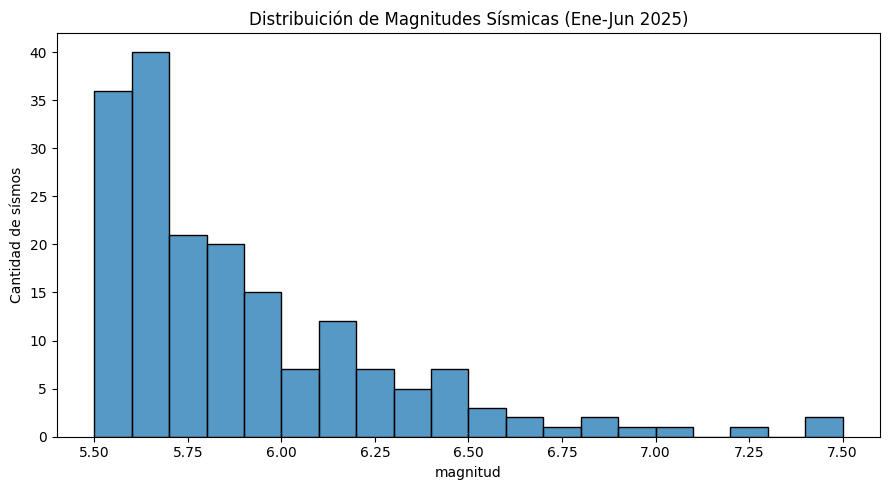

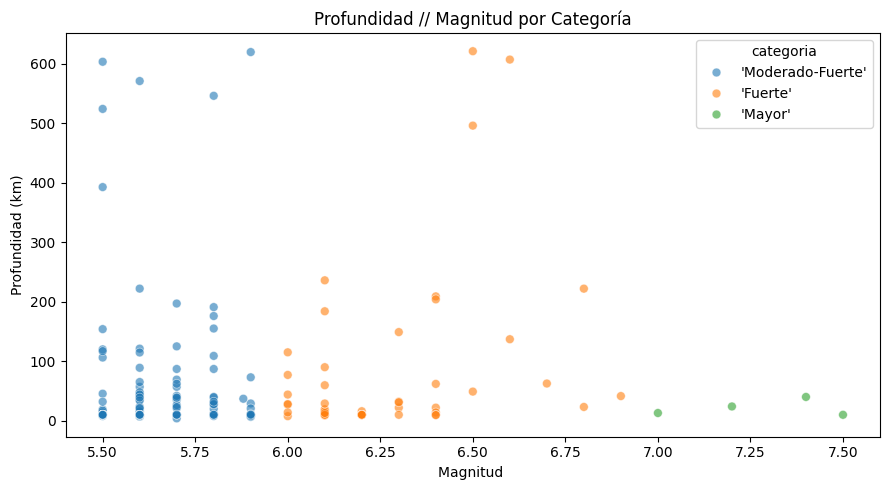

C:\Users\sofig\AppData\Local\Temp\ipykernel_15052\2571441943.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_tipo.index, y=conteo_tipo.values, palette='viridis')


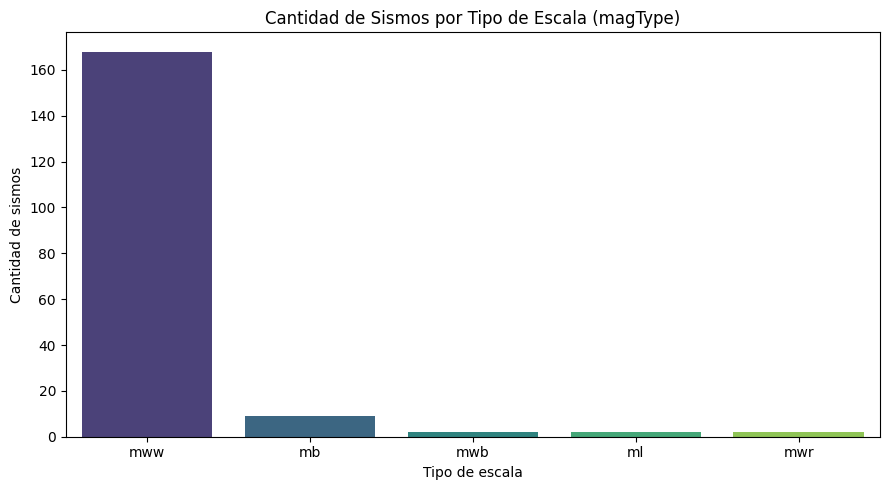

In [48]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: Histograma de magnitudes
plt.figure(figsize=(9, 5))
sns.histplot(data=sismos, x='mag', bins=20)
plt.title("Distribuición de Magnitudes Sísmicas (Ene-Jun 2025)")
plt.xlabel("magnitud")
plt.ylabel("Cantidad de sísmos")
plt.tight_layout()
plt.show()

# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
plt.figure(figsize=(9, 5))
sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)

plt.title("Profundidad // Magnitud por Categoría")
plt.xlabel("Magnitud ")
plt.ylabel("Profundidad (km)")
plt.tight_layout()
plt.show()

# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
plt.figure(figsize=(9, 5))
conteo_tipo = sismos['magType'].value_counts()
sns.barplot(x=conteo_tipo.index, y=conteo_tipo.values, palette='viridis')
plt.title("Cantidad de Sismos por Tipo de Escala (magType)")
plt.xlabel("Tipo de escala")
plt.ylabel("Cantidad de sismos")
plt.tight_layout()
plt.show()


#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media: 5.85  
   - Magnitud máxima: 7.5  
   - Tipo de escala más común (`magType`): mww  
   - Grandes terremotos (mag ≥ 7.0): 4

2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* La distribución es sesgada hacia la derecha, ya que la mayoria se concentra en 5.5 y 6.5

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* No se observa una relacion clara, aunque los sísmos más intensos tienden a ser más superficiales 

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* La escala más usada fué mww, la cual se usa para sísmos de magnitud moderada a grande y es la más presisa para medir la energía liberada, por lo que es la estándar del USGS 


---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [49]:

from poo_sismos import Sismo, CatalogoSismos

# Construir el catálogo con los primeros 50 sismos del DataFrame
catalogo = CatalogoSismos("Sismos USGS — Semestre 1 de 2024")

for indice, fila in sismos.head(50).iterrows():
    s = Sismo(
        lugar       = fila['place'],
        fecha       = fila['time'],
        magnitud    = fila['mag'],
        profundidad = fila['depth'],
        tipo_escala = fila['magType'],
    )
    catalogo.agregar(s)

print(f"Catálogo creado con {len(catalogo)} sismos.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 sismos:")
for sismo in catalogo._sismos[:3]:
    print(" ", sismo)

Catálogo creado con 50 sismos.

Primeros 3 sismos:
  Sismo mag=5.60 | Moderado-Fuerte | Superficial | Lugar: Bouvet Island region | Escala: mww
  Sismo mag=6.10 | Fuerte | Superficial | Lugar: 34 km SW of Atiquipa, Peru | Escala: mww
  Sismo mag=5.70 | Moderado-Fuerte | Superficial | Lugar: 67 km NNW of Houma, Tonga | Escala: mww


In [50]:
# Sismo más intenso del catálogo
mas_intenso = catalogo.el_mas_intenso()
print("Sismo más intenso del catálogo:")
print(" ", mas_intenso)
print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

# Filtrar por categoría
mayores = catalogo.filtrar_por_categoria('Mayor')
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")

# Resumen completo
catalogo.resumen()

Sismo más intenso del catálogo:
  Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww
  ¿Es peligroso? → True

Sismos de categoría 'Mayor' en los primeros 50: 1

  Catalogo : Sismos USGS — Semestre 1 de 2024
  Total    : 50 sismos
  Sismo mas intenso:
    Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww
  Sismos por categoria:
    Moderado-Fuerte   : 38 sismos
    Fuerte            : 11 sismos
    Mayor             : 1 sismos
    Gran terremoto    : 0 sismos


In [51]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

Verificación POO vs. pandas (primeros 10 sismos):
     mag      pandas Ej.3    POO clasificar()      
  ────────────────────────────────────────────────────
    5.60  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR
    6.10         'Fuerte'              Fuerte  ✗ REVISAR
    5.70  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR
    7.20          'Mayor'               Mayor  ✗ REVISAR
    5.90  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR
    5.60  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR
    6.30         'Fuerte'              Fuerte  ✗ REVISAR
    6.00         'Fuerte'              Fuerte  ✗ REVISAR
    5.50  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR
    5.80  'Moderado-Fuerte'     Moderado-Fuerte  ✗ REVISAR


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* EventoSismico es la base genérica que solo tiene lugar y fecha mientras que sismo viene de ella y agrega magnitud, profundidad y tipo_escala. Sismo.__init__ llama a super().__init__(lugar, fecha) para no repetir el código de inicialización, así reutiliza lo que ya estáben EventoSismico.

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* La ventaja es que el método clasificar() está vinculado a Sismo y tiene acceso a self.magnitud sin necesidad de pasarlo como parámetro,  además si se cambia la lógica de clasificación, solo se modifica en un lugar y todos los objetos Sismo lo tomarían automáticamente.

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? Hay 1
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? True
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* El sismo más intenso fue 10 km WSW of Atiquipa, Peru con magnitud 7.20 (≥ 7.0) y profundidad 24.0 km (< 70 km), por lo que cumple ambos criterios de es_peligroso().

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* Aparecen ✗ REVISAR en todos, pero el método clasificar() es correcto. El problema es que la columna categoria de pandas almacena los strings en comillas en la comparación ('Moderado-Fuerte' // Moderado-Fuerte), pero el contenido es idéntico — no requiere corrección en clasificar()

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala?

El sismo más intenso fue el de la Península de Noto, Japón, con magnitud 7.5, clasificado como "Mayor". Tuvo una profundidad superficial de solo 10 km, lo que lo hace muy destructivo en superficie ya que la energía sísmica no tiene tiempo de disiparse antes de llegar a la corteza terrestre.


- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así?

La escala predominante fue mww. Esta es el estándar moderno del USGS para medir la energía total liberada en sismos de magnitud moderada a grande, y es la más precisa y consistente a nivel global.


- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot?

No existe una relación clara entre profundidad y magnitud. Los sismos más intensos tienden a ser superficiales, como el de Japón, pero también hay sismos profundos con magnitudes moderadas como el de Tarauacá, Brasil (621 km, mag 6.5). Esto confirma que la profundidad y la magnitud son variables independientes.

---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

El primer semestre de 2024 registró 183 sismos de magnitud ≥ 5.5 a nivel global, con una magnitud promedio de 5.85, lo que indica una actividad sísmica moderada pero constante. El evento más destacado fue el terremoto de la Península de Noto, Japón, con magnitud 7.5 y profundidad de 10 km, clasificado como "Mayor" y potencialmente muy destructivo por ser superficial. Sobre que aprendí sobre la distribución de magnitudes y profundidades, aprendí que la mayoría de sismos (72.5%) son de categoría "Moderado-Fuerte" y que no existe correlación entre profundidad y magnitud — un sismo puede ser intenso siendo superficial o profundo siendo "moderado". En cuanto a las ventajas de pandas y NumPy sobre un ciclo for manual, son mucho más eficientes: por ejemplo, encontrar los 5 sismos más profundos con sort_values('depth', ascending=False).head() requiere una sola línea, mientras que con un ciclo for necesitaría comparar manualmente cada fila y guardar los resultados. Finalmente, el uso de la escala mww en la mayoría de registros refleja que el USGS prioriza la escala de momento sísmico por ser la más precisa para medir la energía total liberada en eventos de magnitud moderada a grande.




---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [52]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Fausto Geovany Garrido Ruíz
  Carnet       : 202605822
  Fecha/Hora   : 2026-05-17 05:49:57 UTC
  ISS Latitud  : +50.5673 deg
  ISS Longitud : -154.7958 deg
  ISS Hora UTC : 2026-05-17 05:49:55 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
